<div style="text-align: center;">
    <h1 style="
        background: linear-gradient(135deg, #020b22ff, #33485eff);
        color: white; 
        padding: 15px 30px; 
        border-radius: 500px; 
        font-family: 'Segoe UI', Arial, sans-serif; 
        box-shadow: 0 4px 15px rgba(0,0,0,0.3);
        display: inline-block;
    ">
       Facial Recognition System using Convolutional Neural Networks
    </h1>
</div>


<h4 style="color:#96c9ffff">1. Importing TensorFlow, OpenCV, Matplotlib, NumPy libraries for data manipulation and image preprocessing with ImageDataGenerator for training preparation.</h4>


In [6]:
import os, random, math, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
plt.style.use("ggplot")
import cv2
from mtcnn import MTCNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
%matplotlib inline


<h4 style="color:#96c9ffff">2. Setting the path for the LFW dataset images directory to the specified location on the local system.</h4>

In [7]:
DATA_ROOT = Path(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\lfw-deepfunneled")
ALIGNED_ROOT = Path(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\lfw-aligned-128")
ALIGNED_ROOT.mkdir(parents=True, exist_ok=True)
TARGET_SIZE = (128, 128)

<h4 style="color:#96c9ffff">3. Selecting a random person directory and a random image file from the LFW dataset directory for further processing.</h4>

In [8]:
person_dir = random.choice([p for p in DATA_ROOT.iterdir() if p.is_dir()])
img_path = random.choice([p for p in person_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
data = np.fromfile(str(img_path), dtype=np.uint8)
img_bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


<h4 style="color:#96c9ffff">4. Reading a randomly selected image from the file, converting it to both RGB and BGR color formats using OpenCV.</h4>

In [9]:
def align_and_crop(rgb, det, target=(128,128), margin=0.2):
    x, y, w, h = det['box']
    x, y = max(0, x), max(0, y)
    mx, my = int(margin*w), int(margin*h)

    x1, y1 = max(0, x - mx), max(0, y - my)
    x2, y2 = min(rgb.shape[1], x + w + mx), min(rgb.shape[0], y + h + my)

    kps = det.get('keypoints', {})
    if 'left_eye' in kps and 'right_eye' in kps:
        (lx, ly), (rx, ry) = kps['left_eye'], kps['right_eye']
        dy, dx = (ry - ly), (rx - lx)
        angle = np.degrees(np.arctan2(dy, dx))
        M = cv2.getRotationMatrix2D(((x1+x2)//2, (y1+y2)//2), angle, 1.0)
        rot = cv2.warpAffine(rgb, M, (rgb.shape[1], rgb.shape[0]), flags=cv2.INTER_LINEAR)
        crop = rot[y1:y2, x1:x2]
    else:
        crop = rgb[y1:y2, x1:x2]

    if crop.size == 0:
        return None
    return cv2.resize(crop, target, interpolation=cv2.INTER_AREA)

In [10]:
detector = MTCNN()
dets = detector.detect_faces(img_rgb)
MARGIN = 0.20 
def process_image(path_in: Path, path_out: Path) -> bool:
    bgr = cv2.imdecode(np.fromfile(str(path_in), np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        return False
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    dets = detector.detect_faces(rgb)
    if len(dets) == 0:
        return False
    det = max(dets, key=lambda d: d['box'][2]*d['box'][3]) 
    aligned = align_and_crop(rgb, det, target=TARGET_SIZE, margin=MARGIN)
    if aligned is None:
        return False
    path_out.parent.mkdir(parents=True, exist_ok=True)
    cv2.imencode(".jpg", cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR))[1].tofile(str(path_out))
    return True


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\Rammah\anaconda3\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\Rammah\anaconda3\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\Rammah\anaconda3\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


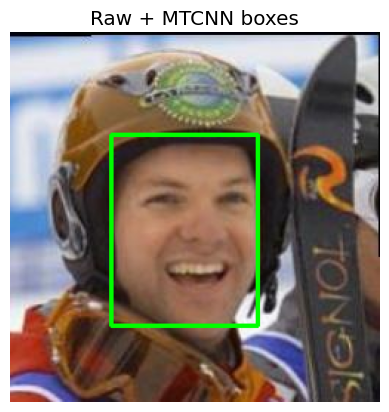

In [11]:
vis = img_rgb.copy()
for d in dets:
    x,y,w,h = d['box']
    x,y = max(0,x), max(0,y)
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 2)
plt.imshow(vis); plt.axis("off"); plt.title("Raw + MTCNN boxes"); plt.show()


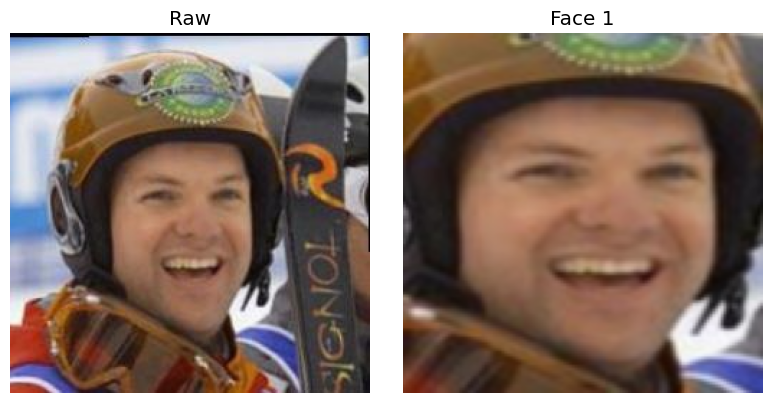

In [12]:
fig, axes = plt.subplots(1, len(dets)+1, figsize=(4*(len(dets)+1), 4))
axes[0].imshow(img_rgb); axes[0].axis("off"); axes[0].set_title("Raw")

for i, det in enumerate(dets, start=1):
    aligned = align_and_crop(img_rgb, det, target=TARGET_SIZE, margin=MARGIN)
    if aligned is not None:
        axes[i].imshow(aligned); axes[i].axis("off"); axes[i].set_title(f"Face {i}")

plt.tight_layout(); plt.show()


In [13]:
ok, fail = 0, 0
valid_exts = [".jpg", ".jpeg", ".png"]
for person in [p for p in DATA_ROOT.iterdir() if p.is_dir()]:
    for img in person.iterdir():
        if img.suffix.lower() not in valid_exts: 
            continue
        dst = ALIGNED_ROOT / person.name / img.name
        if dst.exists(): 
            continue
        if process_image(img, dst):
            ok += 1
        else:
            fail += 1
print(f"Saved aligned faces: {ok} | Failed: {fail}")

Saved aligned faces: 0 | Failed: 1


<h4 style="color:#96c9ffff">5. Displaying the selected person's image before any preprocessing, showing the image in RGB format using Matplotlib.</h4>

In [14]:
widths, heights, areas = [], [], []
for img_path in DATA_ROOT.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        try:
            img = cv2.imdecode(np.fromfile(str(img_path), np.uint8), cv2.IMREAD_COLOR)
            if img is None: 
                continue
            h, w = img.shape[:2]
            widths.append(w); heights.append(h); areas.append(w*h)
        except Exception as e:
            print("Could not open:", img_path, "| Error:", e)

print(f"Total images processed: {len(areas)}")
print("Width:  min/max/median:", min(widths), max(widths), float(np.median(widths)))
print("Height: min/max/median:", min(heights), max(heights), float(np.median(heights)))
print("Area:   min/max/median:", min(areas), max(areas), float(np.median(areas)))


Total images processed: 13233
Width:  min/max/median: 250 250 250.0
Height: min/max/median: 250 250 250.0
Area:   min/max/median: 62500 62500 62500.0


Total aligned images: 13232
Width (min/max/median): 128 128 128.0
Height (min/max/median): 128 128 128.0


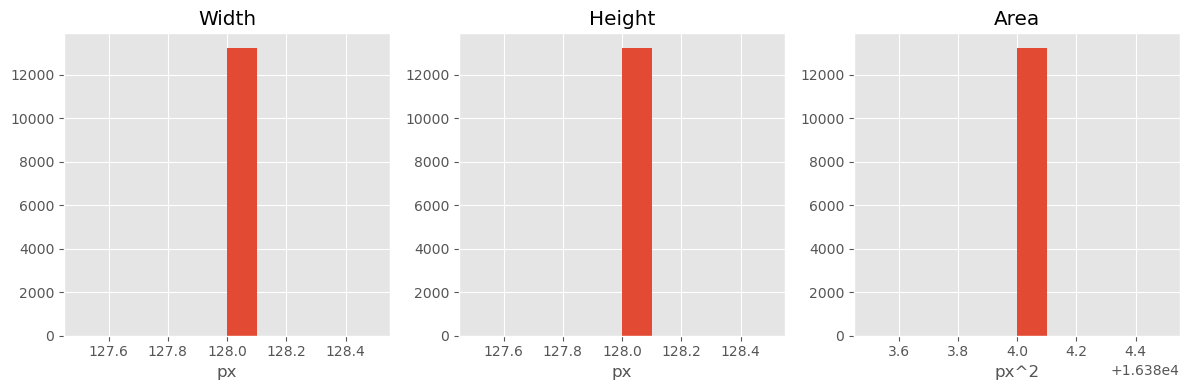

In [15]:
w2, h2, a2 = [], [], []
for img_path in ALIGNED_ROOT.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        try:
            im = cv2.imdecode(np.fromfile(str(img_path), np.uint8), cv2.IMREAD_COLOR)
            if im is None: 
                continue
            h, w = im.shape[:2]
            w2.append(w); h2.append(h); a2.append(w*h)
        except Exception as e:
            print("Could not open:", img_path, "|", e)

print("Total aligned images:", len(a2))
print("Width (min/max/median):", min(w2), max(w2), float(np.median(w2)))
print("Height (min/max/median):", min(h2), max(h2), float(np.median(h2)))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.hist(w2, bins=10); plt.title("Width");  plt.xlabel("px")
plt.subplot(1,3,2); plt.hist(h2, bins=10); plt.title("Height"); plt.xlabel("px")
plt.subplot(1,3,3); plt.hist(a2, bins=10); plt.title("Area");   plt.xlabel("px^2")
plt.tight_layout(); plt.show()

<h4 style="color:#96c9ffff">7. Detecting faces in the image using Haar Cascade Classifier and converting the image to grayscale for face detection.</h4>

In [16]:
matchpairsDevTest_df = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\matchpairsDevTest.csv")
print("Total pairs:", len(matchpairsDevTest_df))
print("Unique people:", matchpairsDevTest_df["name"].nunique())


Total pairs: 500
Unique people: 353


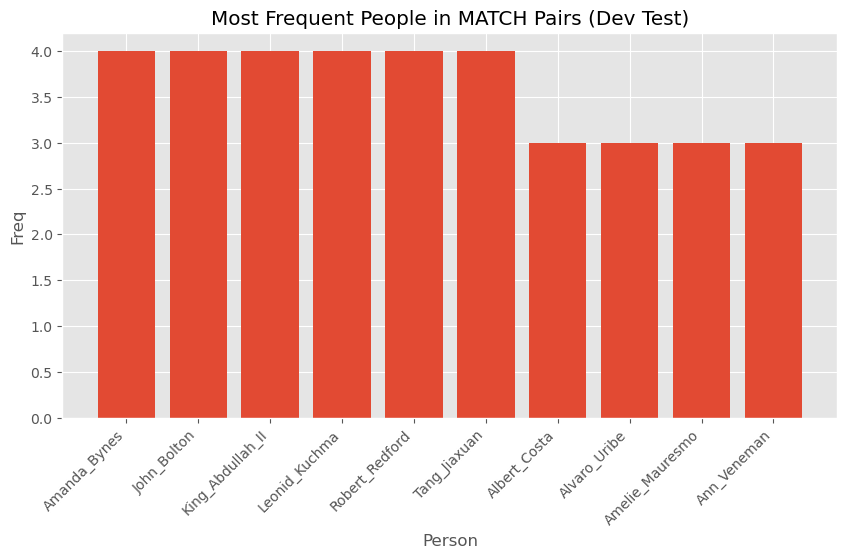

In [17]:
counts_match_test = Counter(matchpairsDevTest_df["name"])
top10 = dict(sorted(counts_match_test.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(10,5))
plt.bar(top10.keys(), top10.values()); plt.xticks(rotation=45, ha="right")
plt.title("Most Frequent People in MATCH Pairs (Dev Test)"); plt.xlabel("Person"); plt.ylabel("Freq")
plt.show()

<h4 style="color:#96c9ffff">8. Detecting faces using Haar Cascade, applying a margin around the detected face, and cropping the face region from the image for further processing.</h4>

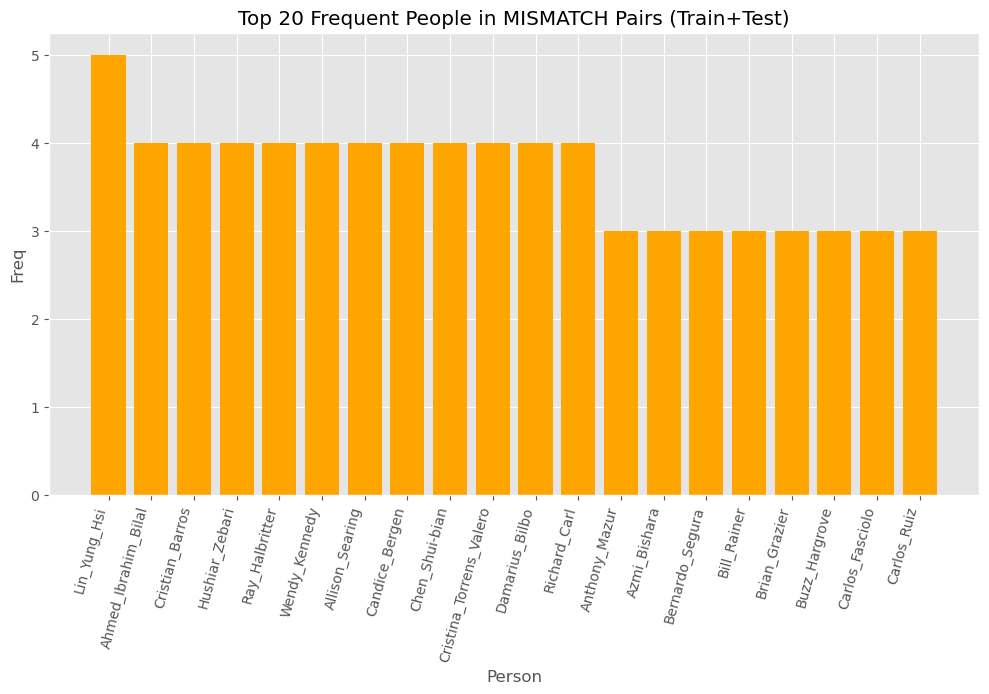

In [18]:
mismatchpairsDevTrain_df = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\mismatchpairsDevTrain.csv")
mismatchpairsDevTest_df = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\mismatchpairsDevTest.csv")

counts_train = Counter(mismatchpairsDevTrain_df["name"]) + Counter(mismatchpairsDevTrain_df["name.1"])
counts_test  = Counter(mismatchpairsDevTest_df["name"])  + Counter(mismatchpairsDevTest_df["name.1"])
total_counts = counts_train + counts_test

top20 = dict(sorted(total_counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(12,6))
plt.bar(top20.keys(), top20.values(), color="orange"); plt.xticks(rotation=75, ha="right")
plt.title("Top 20 Frequent People in MISMATCH Pairs (Train+Test)"); plt.xlabel("Person"); plt.ylabel("Freq")
plt.show()


In [19]:
pairs_test = mismatchpairsDevTest_df.apply(lambda r: tuple(sorted([(r["name"], int(r["imagenum1"])), (r["name.1"], int(r["imagenum2"]))])),axis=1)
print("Undirected duplicate pairs in test:", pd.Series(pairs_test).duplicated().sum())

Undirected duplicate pairs in test: 0


<h4 style="color:#96c9ffff">9. Drawing the detected face bounding box on the original RGB image (convert to BGR for OpenCV drawing, draw rectangle with (x1,y1)-(x2,y2), then convert back to RGB for display).</h4>

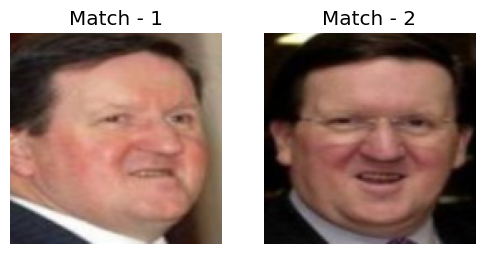

In [20]:
base_aligned = ALIGNED_ROOT

row = matchpairsDevTest_df.sample(1).iloc[0]
person = row["name"]
img1 = base_aligned / person / f"{person}_{int(row['imagenum1']):04d}.jpg"
img2 = base_aligned / person / f"{person}_{int(row['imagenum2']):04d}.jpg"
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(plt.imread(img1)); ax[0].axis("off"); ax[0].set_title("Match - 1")
ax[1].imshow(plt.imread(img2)); ax[1].axis("off"); ax[1].set_title("Match - 2")
plt.show()


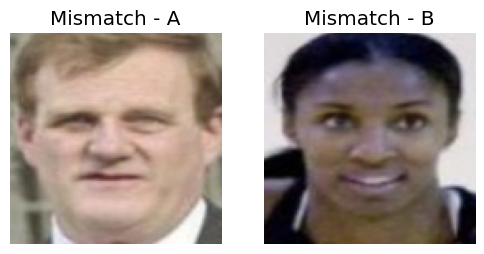

In [21]:
row = mismatchpairsDevTest_df.sample(1).iloc[0]
p1 = row["name"];    i1 = base_aligned / p1 / f"{p1}_{int(row['imagenum1']):04d}.jpg"
p2 = row["name.1"];  i2 = base_aligned / p2 / f"{p2}_{int(row['imagenum2']):04d}.jpg"
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(plt.imread(i1)); ax[0].axis("off"); ax[0].set_title("Mismatch - A")
ax[1].imshow(plt.imread(i2)); ax[1].axis("off"); ax[1].set_title("Mismatch - B")
plt.show()

<h4 style="color:#96c9ffff">10. Displaying the original image with the face detection rectangle and the cropped face side by side for comparison.</h4>

In [22]:
def plot_images(images_arr):
    fig, axes = plt.subplots(1, min(10, len(images_arr)), figsize=(20, 2.2))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img.astype(np.uint8)); ax.axis('off')
    plt.tight_layout(); plt.show()


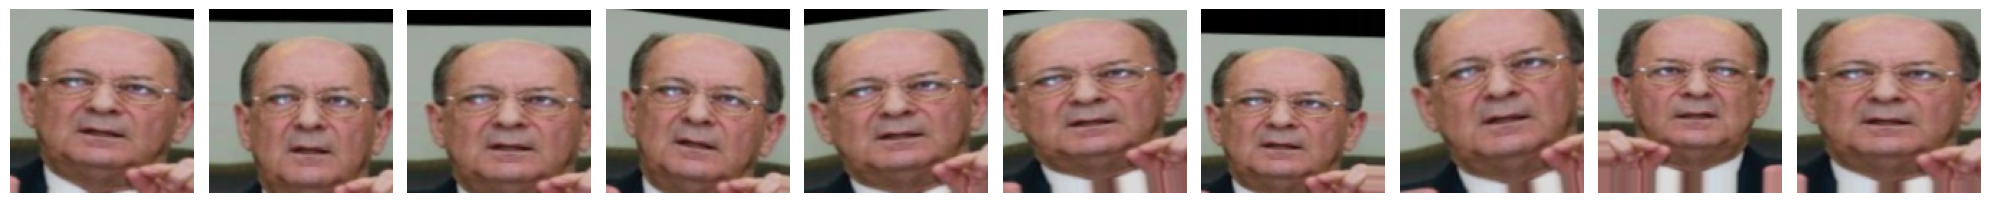

In [23]:
person_dir = random.choice([p for p in ALIGNED_ROOT.iterdir() if p.is_dir()])
image_path = random.choice(list(person_dir.glob("*.jpg")))
image = np.expand_dims(plt.imread(image_path), 0) 

gen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,shear_range=0.1, zoom_range=0.1, horizontal_flip=True)
aug_iter = gen.flow(image, batch_size=1)
aug_images = [next(aug_iter)[0] for _ in range(10)]
plot_images(aug_images)

<h4 style="color:#96c9ffff">11. Applying CLAHE to the cropped face by equalizing the Y channel in YCrCb space, converting back to RGB, and normalizing to [0,1] for illumination enhancement.</h4>

In [24]:
save_dir = Path(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented")
save_dir.mkdir(parents=True, exist_ok=True)

img_in = image.copy()
if img_in.dtype in (np.float32, np.float64) and img_in.max() <= 1.0:
    img_in = (img_in * 255).astype("uint8")

gen_save = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,shear_range=0.1, zoom_range=0.1, horizontal_flip=True)

aug_iter = gen_save.flow(img_in, batch_size=1, save_to_dir=str(save_dir), save_prefix='aug-image-', save_format='jpeg')

num_to_save = 20

for _ in range(num_to_save):
    next(aug_iter)
    time.sleep(0.02)  
print("Saved", num_to_save, "augmented images to:", save_dir)


Saved 20 augmented images to: C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented


<h4 style="color:#96c9ffff">12. Displaying the original cropped face and the cropped face after applying CLAHE side by side to compare the illumination enhancement.</h4>

In [25]:
apply_clahe = True
img = plt.imread(image_path)  
if img.dtype != np.uint8:
    img8 = (img * 255).astype("uint8") if img.max() <= 1.0 else img.astype("uint8")
else:
    img8 = img

if apply_clahe:
    ycc = cv2.cvtColor(img8, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycc)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    y_eq = clahe.apply(y)
    eq_rgb = cv2.cvtColor(cv2.merge([y_eq, cr, cb]), cv2.COLOR_YCrCb2RGB)
else:
    eq_rgb = img8


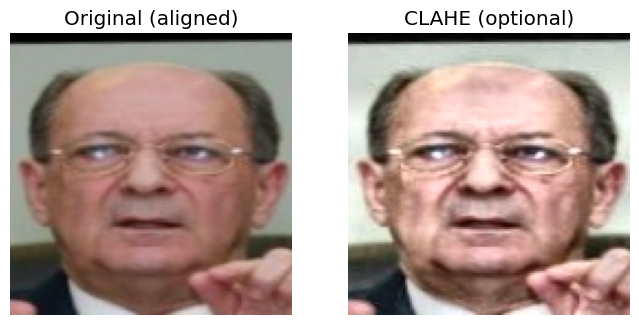

In [26]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img8);   plt.axis("off"); plt.title("Original (aligned)")
plt.subplot(1,2,2); plt.imshow(eq_rgb); plt.axis("off"); plt.title("CLAHE (optional)")
plt.show()

### All images in the LFW Deepfunneled dataset are preprocessed to have a fixed resolution of 250×250 pixels. This explains why the histograms of width, height, and area show a single spike — there is no variation in image dimensions. Any variability in the dataset comes from the pixel intensity values (color/brightness), not from the image sizes.

In [27]:
matchpairsDevTest_df = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\matchpairsDevTest.csv")
print("Total pairs:", len(matchpairsDevTest_df))
print("Unique people:", matchpairsDevTest_df["name"].nunique())
print(matchpairsDevTest_df.head())


Total pairs: 500
Unique people: 353
               name  imagenum1  imagenum2
0      Abdullah_Gul         13         14
1      Abdullah_Gul         13         16
2  Abdullatif_Sener          1          2
3    Adel_Al-Jubeir          1          3
4         Al_Pacino          1          2


In [28]:
all_imgs = pd.concat([matchpairsDevTest_df["imagenum1"], matchpairsDevTest_df["imagenum2"]])
print("Unique images referenced:", all_imgs.nunique())


Unique images referenced: 35


In [29]:
from collections import Counter
counts = Counter(all_imgs)
print("Most used image indices:", counts.most_common(10))


Most used image indices: [(1, 292), (2, 288), (3, 141), (4, 84), (5, 39), (6, 30), (8, 17), (7, 16), (10, 13), (9, 11)]


In [30]:


base = Path(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\lfw-aligned-128")


row = matchpairsDevTest_df.sample(1).iloc[0]
person = row["name"]
img1 = base / person / f"{person}_{int(row['imagenum1']):04d}.jpg"
img2 = base / person / f"{person}_{int(row['imagenum2']):04d}.jpg"

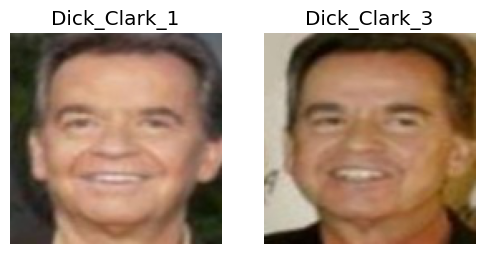

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(Image.open(img1))
axes[0].set_title(f"{person}_{row['imagenum1']}")
axes[0].axis("off")

axes[1].imshow(Image.open(img2))
axes[1].set_title(f"{person}_{row['imagenum2']}")
axes[1].axis("off")
plt.show()


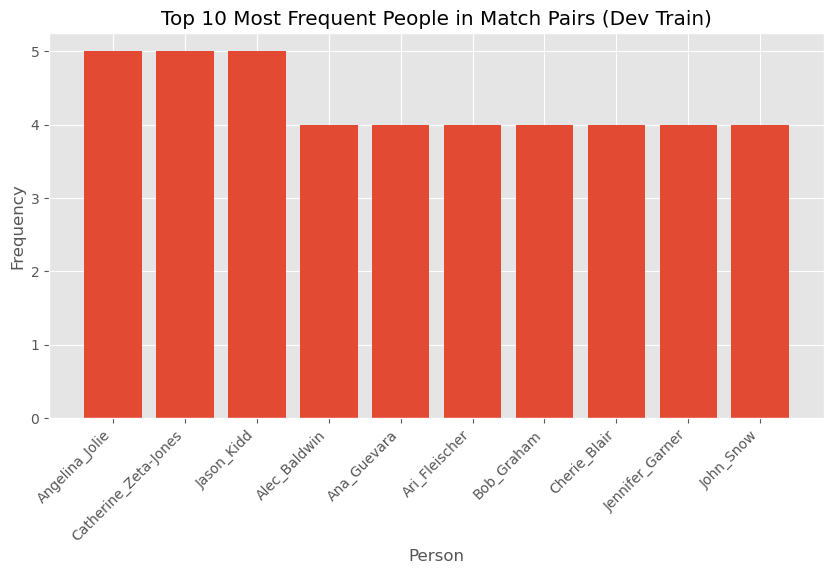

In [32]:
matchpairsDevTrain_df=pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\matchpairsDevTrain.csv")
counts = Counter(matchpairsDevTrain_df["name"])

top10 = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(10,5))
plt.bar(top10.keys(), top10.values())
plt.title("Top 10 Most Frequent People in Match Pairs (Dev Train)")
plt.xlabel("Person")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.show()


### This checks if the same mismatched pair appears more than once in the dataset.
### Duplicate pairs could bias training and reduce variety in negative examples.


In [33]:
Test_duplicates = matchpairsDevTest_df.duplicated().sum()
print("Duplicate mismatched pairs in test data:", Test_duplicates)
Train_duplicates = matchpairsDevTrain_df.duplicated().sum()
print("Duplicate mismatched pairs in train data:", Train_duplicates)


Duplicate mismatched pairs in test data: 0
Duplicate mismatched pairs in train data: 0


#### This code loads a dataset of mismatched face pairs (mismatchpairsDevTest.csv) from the LFW-deepfunneled dataset and randomly selects one pair for visualization. Each row in the file contains two different people with their corresponding image numbers. The script constructs the image file paths using the person’s name and image number, then loads the images with PIL. Finally, it displays the two images side by side using Matplotlib, with titles showing the person’s name and image number. This allows us to visually inspect mismatched pairs and confirm that the dataset correctly represents faces of different individuals.

In [34]:
row = mismatchpairsDevTest_df.sample(1).iloc[0]
plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

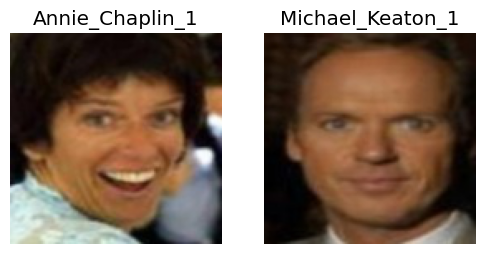

In [35]:
person1 = row["name"]
img1 = base / person1 / f"{person1}_{int(row['imagenum1']):04d}.jpg"

person2 = row["name.1"]
img2 = base / person2 / f"{person2}_{int(row['imagenum2']):04d}.jpg"

fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(Image.open(img1))
axes[0].set_title(f"{person1}_{row['imagenum1']}")
axes[0].axis("off")

axes[1].imshow(Image.open(img2))
axes[1].set_title(f"{person2}_{row['imagenum2']}")
axes[1].axis("off")


In [36]:
mismatchpairsDevTrain_df = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\mismatchpairsDevTrain.csv")

row = mismatchpairsDevTrain_df.sample(1).iloc[0]

person1 = row["name"]
img1 = base / person1 / f"{person1}_{int(row['imagenum1']):04d}.jpg"


person2 = row["name.1"]
img2 = base / person2 / f"{person2}_{int(row['imagenum2']):04d}.jpg"


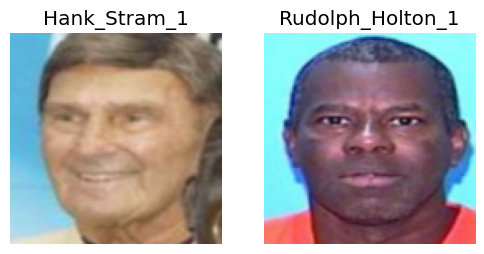

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(Image.open(img1))
axes[0].set_title(f"{person1}_{row['imagenum1']}")
axes[0].axis("off")

axes[1].imshow(Image.open(img2))
axes[1].set_title(f"{person2}_{row['imagenum2']}")
axes[1].axis("off")

plt.show()

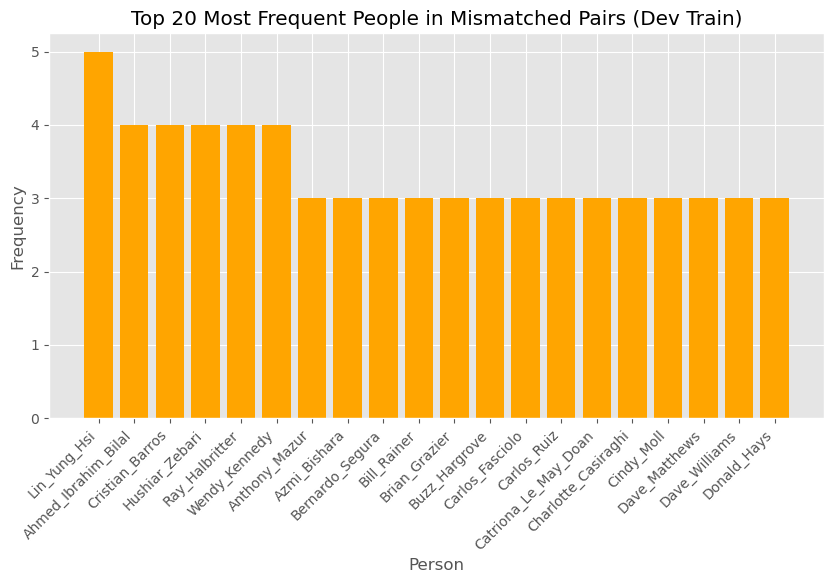

In [38]:

counts = Counter(mismatchpairsDevTrain_df["name"]) + Counter(mismatchpairsDevTrain_df["name.1"])

top20 = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(10,5))
plt.bar(top20.keys(), top20.values(), color="orange")
plt.title("Top 20 Most Frequent People in Mismatched Pairs (Dev Train)")
plt.xlabel("Person")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.show()


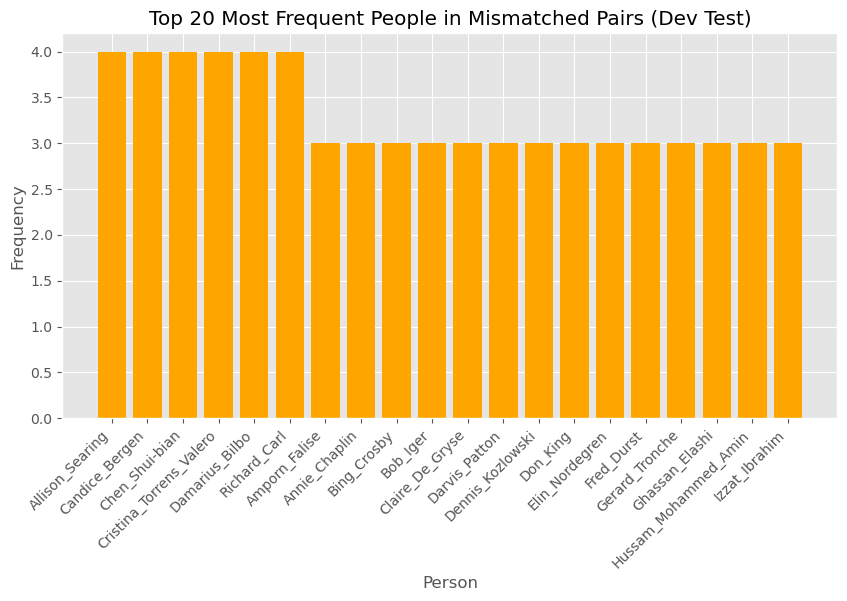

In [39]:
counts = Counter(mismatchpairsDevTest_df["name"]) + Counter(mismatchpairsDevTest_df["name.1"])

top20 = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(10,5))
plt.bar(top20.keys(), top20.values(), color="orange")
plt.title("Top 20 Most Frequent People in Mismatched Pairs (Dev Test)")
plt.xlabel("Person")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.show()


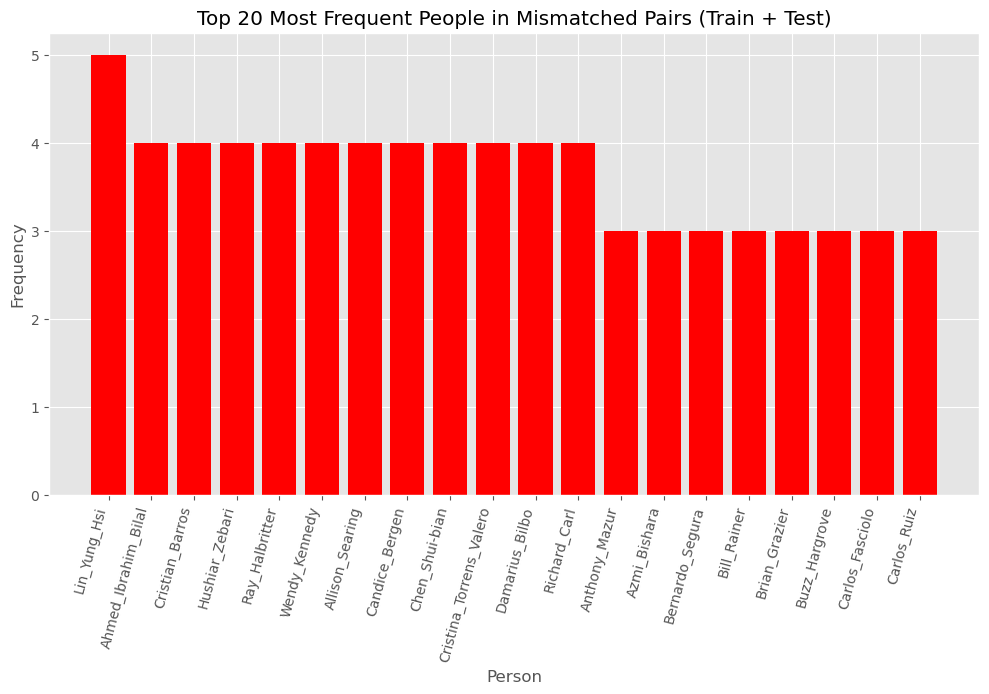

In [40]:
counts_train = Counter(mismatchpairsDevTrain_df["name"]) + Counter(mismatchpairsDevTrain_df["name.1"])
counts_test = Counter(mismatchpairsDevTest_df["name"]) + Counter(mismatchpairsDevTest_df["name.1"])
total_counts = counts_train + counts_test

top20 = dict(sorted(total_counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(12,6))
plt.bar(top20.keys(), top20.values(), color="red")
plt.title("Top 20 Most Frequent People in Mismatched Pairs (Train + Test)")
plt.xlabel("Person")
plt.ylabel("Frequency")
plt.xticks(rotation=75, ha="right")
plt.show()


importing all the libraries we use.

In [41]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

We define this variable called gen as an ImageDataGenerator. All the parameters being passed are the different ways we're telling Keras to augment the image.

In [42]:
gen = ImageDataGenerator(rotation_range=90, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.15, zoom_range=0.1, channel_shift_range=10., horizontal_flip=True)

We choose a random image of a person from the file and print that person's name and path.

In [43]:
chosen_person = random.choice(os.listdir(base))
person_path = os.path.join(base, chosen_person)

chosen_image = random.choice(os.listdir(person_path))
image_path = os.path.join(person_path, chosen_image)

print("Person:", chosen_person)
print("Image path:", image_path)


Person: Marie-Josee_Croze
Image path: C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\lfw-aligned-128\Marie-Josee_Croze\Marie-Josee_Croze_0001.jpg


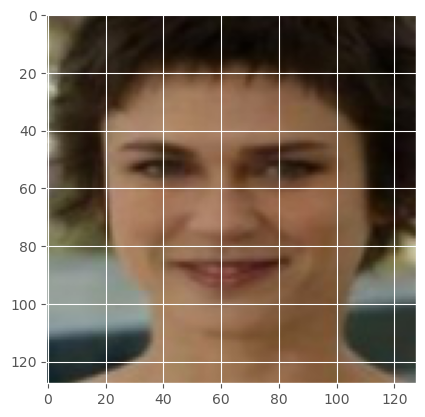

In [44]:
image = np.expand_dims(plt.imread(image_path),0)
plt.imshow(image[0])

We generate batches of augmented images from the original image.
The flow() function takes NumPy data and generates batches of augmented data.
We get ten samples of the augmented images and plot them.

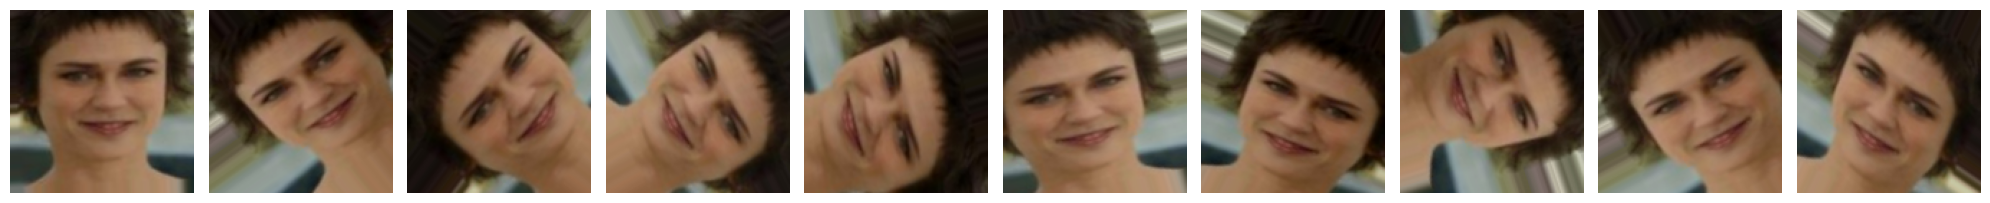

In [45]:
aug_iter = gen.flow(image)
aug_images = [next(aug_iter)[0].astype(np.uint8) for i in range(10)]
plotImages(aug_images)


Now we create a new folder to save the augmented images with the prefix aug_image_, and then print the path.

In [46]:

num_to_save = 36  
save_dir = r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented"

os.makedirs(save_dir, exist_ok=True)

img_in = image.copy() 
if img_in.dtype in (np.float32, np.float64) and img_in.max() <= 1.0:
    img_in = (img_in * 255).astype("uint8") 

gen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,shear_range=0.1, zoom_range=0.1, horizontal_flip=True)

aug_iter = gen.flow(img_in,save_to_dir=save_dir,save_prefix='aug-image-',save_format='jpeg',batch_size=1)
seen = set(os.listdir(save_dir))

In [47]:
for _ in range(num_to_save):
    next(aug_iter)
    time.sleep(0.02)  

now = set(os.listdir(save_dir))
new_files = sorted([f for f in (now - seen) if f.startswith('aug-image-') and f.endswith('.jpeg')])

new_files = new_files[:num_to_save]

In [48]:
print("Saved files:")
for i, f in enumerate(new_files, 1):
    print(f"{i:02d}. {os.path.join(save_dir, f)}")

Saved files:
01. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_1247.jpeg
02. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_1470.jpeg
03. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_2061.jpeg
04. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_2097.jpeg
05. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_25.jpeg
06. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_2541.jpeg
07. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_2620.jpeg
08. C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\augmented\aug-image-_0_2900.jpeg
09. C

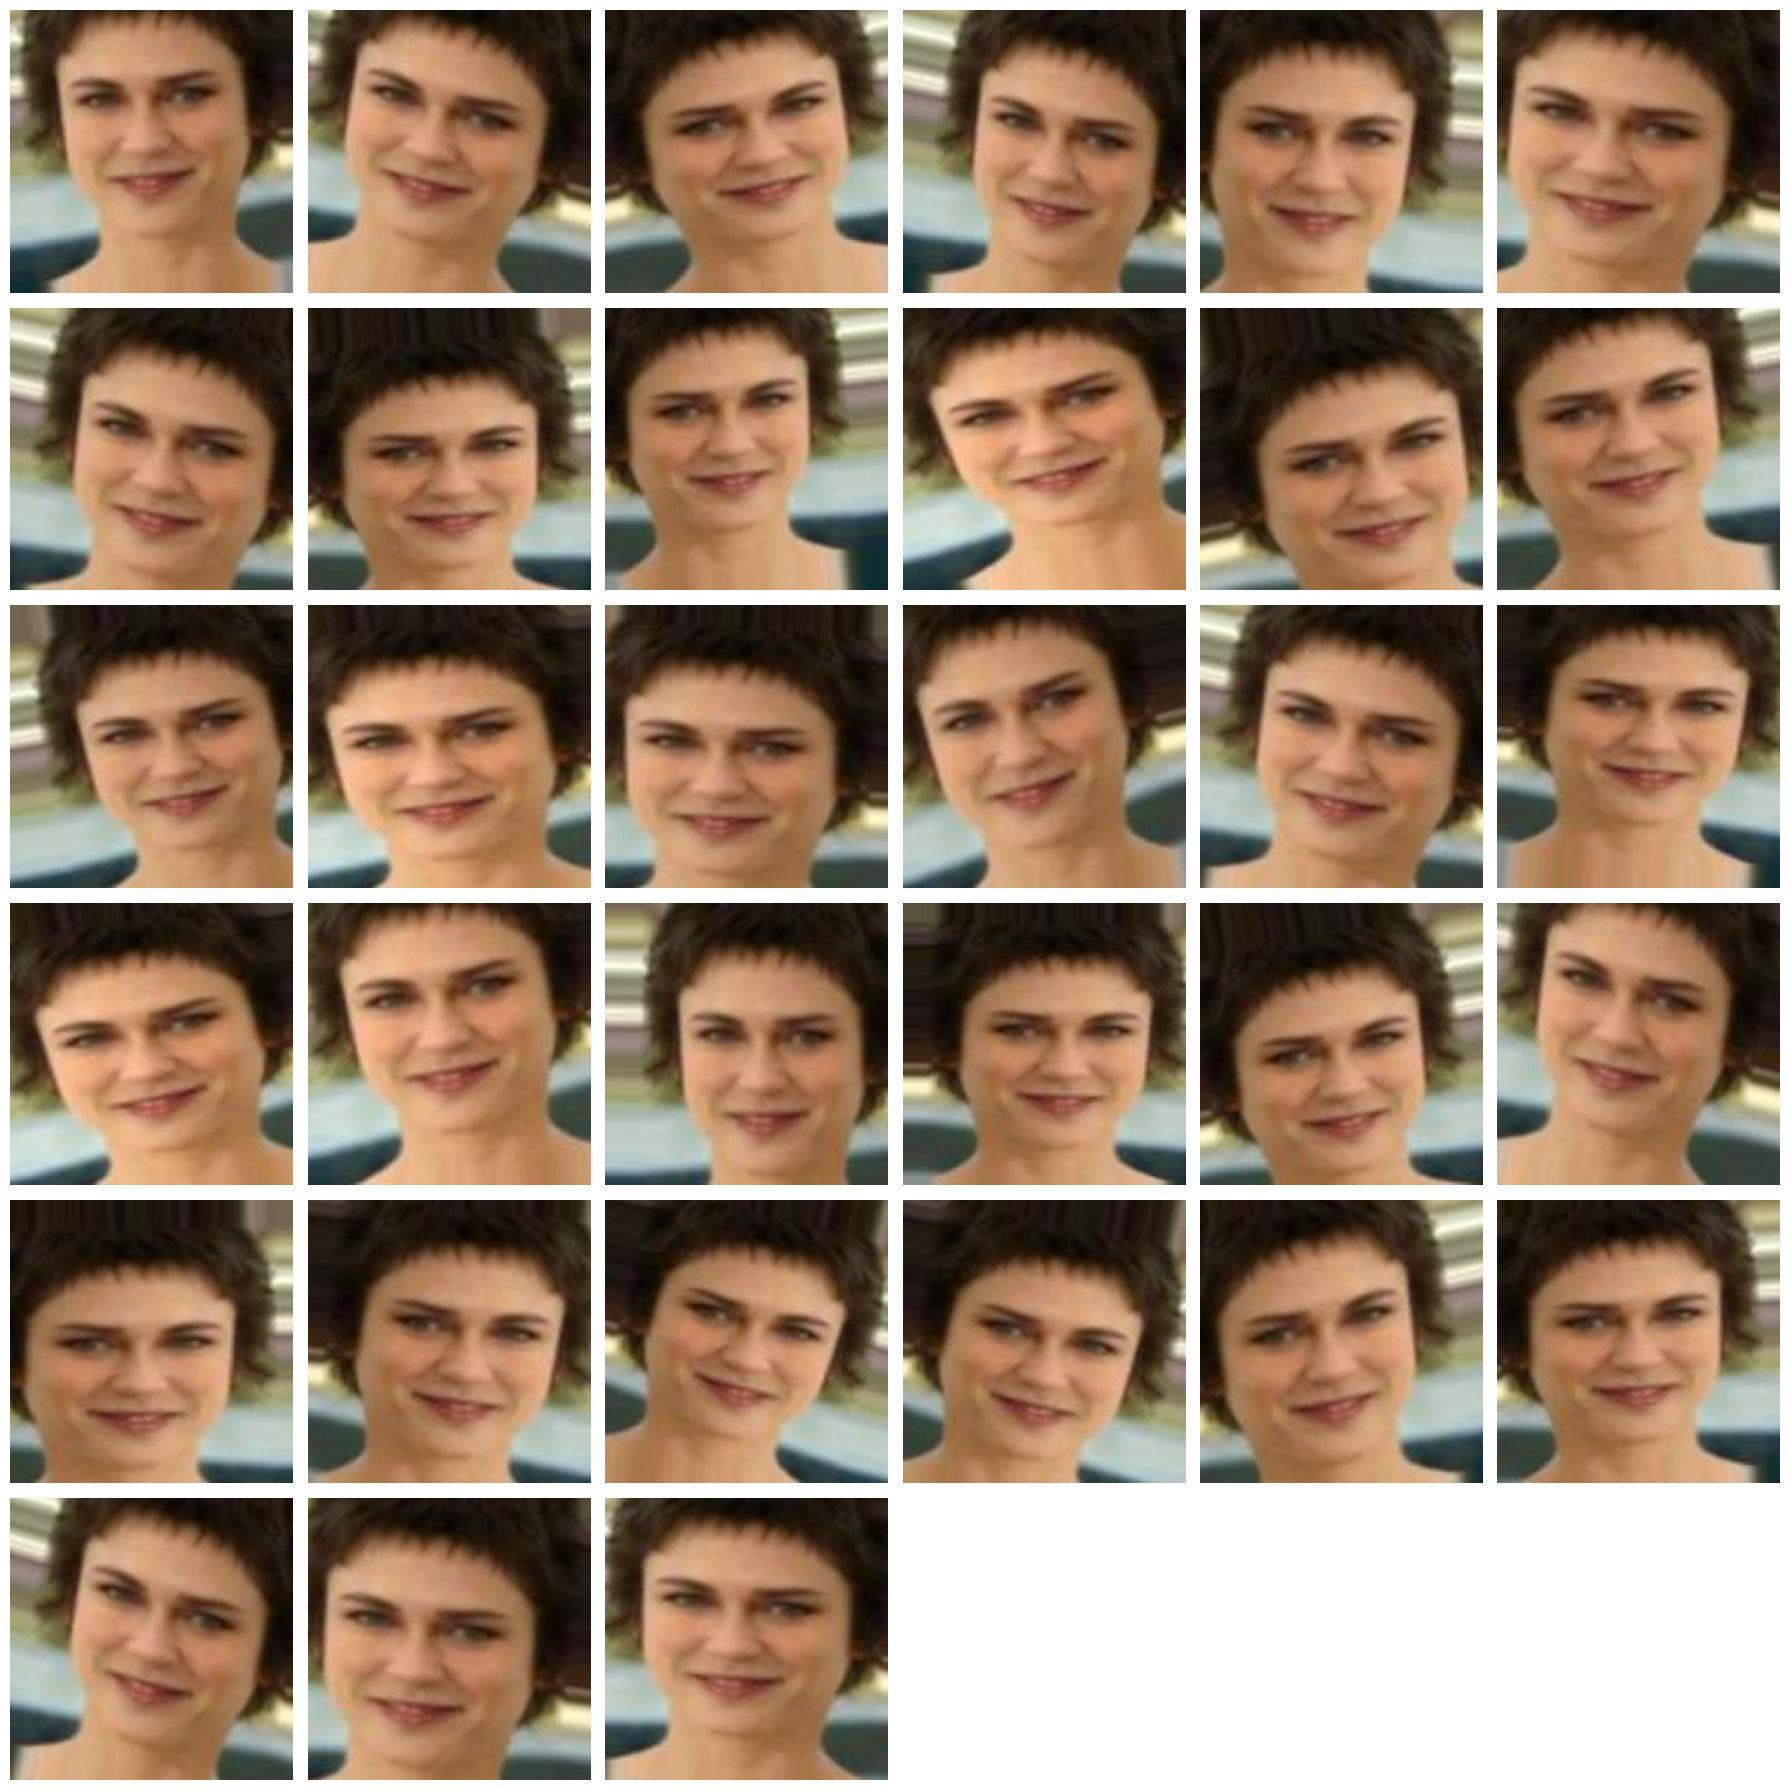

In [49]:
paths = [os.path.join(save_dir, f) for f in new_files]
cols = min(6, len(paths))
rows = math.ceil(len(paths) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
if rows == 1:
    axes = np.array(axes).reshape(1, -1)
axes = axes.flatten()
for ax, p in zip(axes, paths):
    img = plt.imread(p)
    ax.imshow(img)
    ax.axis("off")

for i in range(len(paths), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
BASE = Path(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Final Project\Facial Recognition System\Data\lfw-aligned-128")

match_train  = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Final Project\Facial Recognition System\Data\matchpairsDevTrain.csv")
mismatch_train = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Final Project\Facial Recognition System\Data\mismatchpairsDevTrain.csv")
match_test   = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Final Project\Facial Recognition System\Data\matchpairsDevTest.csv")
mismatch_test  = pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Final Project\Facial Recognition System\Data\mismatchpairsDevTest.csv")

def path_for(person, imagenum):
    return str(BASE / person / f"{person}_{int(imagenum):04d}.jpg")

def build_pairs(match_df, mismatch_df):
    # match: name, imagenum1, imagenum2
    match_pairs = [(path_for(r["name"], r["imagenum1"]),
                    path_for(r["name"], r["imagenum2"]), 1) for _, r in match_df.iterrows()]
    # mismatch: name, imagenum1, name.1, imagenum2
    mismatch_pairs = [(path_for(r["name"], r["imagenum1"]),
                       path_for(r["name.1"], r["imagenum2"]), 0) for _, r in mismatch_df.iterrows()]
    pairs = match_pairs + mismatch_pairs
    np.random.shuffle(pairs)
    return pairs

train_pairs = build_pairs(match_train, mismatch_train)
test_pairs  = build_pairs(match_test, mismatch_test)

IMG_SIZE = (128,128)

def read_image(path):
    data = tf.io.read_file(path)
    img  = tf.image.decode_jpeg(data, channels=3) 
    img  = tf.image.resize(img, IMG_SIZE)         
    img  = tf.cast(img, tf.float32)                
    return img

def augment(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img

def make_ds(pairs, batch=64, training=True):
    paths1 = [p[0] for p in pairs]
    paths2 = [p[1] for p in pairs]
    labels = [p[2] for p in pairs]
    ds = tf.data.Dataset.from_tensor_slices((paths1, paths2, labels))
    def _map(p1, p2, y):
        i1 = read_image(p1)
        i2 = read_image(p2)
        if training:
            i1 = augment(i1); i2 = augment(i2)
        return (i1, i2), tf.cast(y, tf.float32)
    ds = ds.shuffle(min(len(labels), 20000)) if training else ds
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_pairs, batch=128, training=True)
test_ds  = make_ds(test_pairs,  batch=256, training=False)

In [55]:
from tensorflow.keras import layers, models, applications, optimizers

EMB_DIM = 128

def build_backbone():
    base = applications.MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
    base.trainable = False

    # مهم: MobileNetV2 يتوقع إدخال preprocess_input
    inp = layers.Input((128,128,3))
    x = applications.mobilenet_v2.preprocess_input(inp)
    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(EMB_DIM, use_bias=False, name="emb_dense")(x)

    # بدل tf.math.l2_normalize المباشر → Lambda
    emb = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1), name="l2_norm")(x)
    return models.Model(inp, emb, name="embedder")


In [56]:
embedder = build_backbone()

def siamese_model():
    inp1 = layers.Input((128,128,3))
    inp2 = layers.Input((128,128,3))
    e1 = embedder(inp1)
    e2 = embedder(inp2)

    # cosine similarity مباشرة من Keras
    cos = layers.Dot(axes=-1, normalize=True, name="cosine")([e1, e2])  # شكل (batch,)
    prob = layers.Lambda(lambda c: (c + 1.0) / 2.0, name="to_prob")(cos)  # إلى [0,1]
    prob = layers.Reshape((1,))(prob)  # اختياري: اجعلها (batch,1)
    return models.Model([inp1, inp2], prob, name="siamese")

model = siamese_model()
model.compile(optimizer=optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [57]:
ckpt = tf.keras.callbacks.ModelCheckpoint(
    filepath="siamese_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[ckpt, es]
)
model.save("siamese_final.keras")


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 726ms/step - accuracy: 0.4873 - loss: 0.7952 - val_accuracy: 0.5000 - val_loss: 3.6106
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 608ms/step - accuracy: 0.5041 - loss: 0.7211 - val_accuracy: 0.5000 - val_loss: 3.4569
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5073 - loss: 0.7129 - val_accuracy: 0.5000 - val_loss: 3.4948
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 756ms/step - accuracy: 0.5077 - loss: 0.7113 - val_accuracy: 0.5000 - val_loss: 3.8946
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 935ms/step - accuracy: 0.5068 - loss: 0.7105 - val_accuracy: 0.5000 - val_loss: 3.6659
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5027 - loss: 0.7104 - val_accuracy: 0.5000 - val_loss: 3.7650


In [60]:
import numpy as np
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score

# تنبؤات على test
y_true = []
y_prob = []
for (i1,i2), y in test_ds:
    p = model.predict([i1,i2], verbose=0).ravel()
    y_prob.append(p); y_true.append(y.numpy())
y_prob = np.concatenate(y_prob)
y_true = np.concatenate(y_true)

fpr, tpr, thr = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

# دالة لمقاييس عند threshold
def metrics_at(th):
    y_pred = (y_prob >= th).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec= precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    far = fpr[np.argmin(np.abs(thr - th))]  # FAR ~ FPR (positive=match)
    frr = 1 - rec
    return acc, prec, rec, far, frr

# اختَر threshold يحقق FAR ≈ 1%
target_far = 0.01
idx = np.argmin(np.abs(fpr - target_far))
th_star = thr[idx]
acc, prec, rec, far, frr = metrics_at(th_star)
print(f"Chosen threshold: {th_star:.3f}")
print(f"ACC={acc:.3f} | PREC={prec:.3f} | REC={rec:.3f} | FAR={far:.3f} | FRR={frr:.3f}")


ROC AUC: 0.660612
Chosen threshold: 1.000
ACC=0.535 | PREC=0.889 | REC=0.080 | FAR=0.010 | FRR=0.920


In [59]:
for layer in embedder.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
model.compile(optimizers.Adam(5e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=test_ds, epochs=10, callbacks=[ckpt, es])


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.5268 - loss: 0.6965 - val_accuracy: 0.5000 - val_loss: 3.6753
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.5868 - loss: 0.6673 - val_accuracy: 0.5000 - val_loss: 3.7772
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6318 - loss: 0.6519 - val_accuracy: 0.5000 - val_loss: 3.8784
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6664 - loss: 0.6360 - val_accuracy: 0.5000 - val_loss: 3.8520
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.7032 - loss: 0.6203 - val_accuracy: 0.5000 - val_loss: 3.7538


In [61]:
same = read_image(train_pairs_sub[0][0])[None,...]
s1 = model.predict([same, same], verbose=0)[0,0]
print("same vs same:", s1)  # لازم يبقى عالي ~0.8+

neg = next(p for p in train_pairs_sub if p[2]==0)
i1 = read_image(neg[0])[None,...]; i2 = read_image(neg[1])[None,...]
s2 = model.predict([i1, i2], verbose=0)[0,0]
print("diff vs diff:", s2)  # لازم يبقى أوطى بوضوح

NameError: name 'train_pairs_sub' is not defined